In [96]:
import numpy as np
from tensorflow.keras.models import load_model

In [97]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, RobustScaler
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

In [98]:
import sys
sys.path.append('../data_preprocessing')

In [99]:
import feature_engineering_scaling as fes

In [100]:
# Load the saved models
model_1_2 = load_model("../models/model_ann_214.h5")  # Model for classifying 0, 1, 2, 3
model_4_5 = load_model("../models/model_ann_212.h5")  # Model for classifying 0, 3, 4, 5

# Functions

In [101]:
# Min-Max Unscaling Function
def minmax_unscaler(X_unscaled, X_scaled, columns):
    """
    Unscale X_test using the min and max values derived from the original X data.
    
    Parameters:
    - X_unscaled: Original (unscaled) data.
    - X_scaled: Scaled data (after MinMaxScaler).
    - columns: List of columns to be unscaled.
    
    Returns:
    - X_scaled: DataFrame with columns unscaled.
    """
    min_vals = X_unscaled[columns].min()
    max_vals = X_unscaled[columns].max()
    
    # Formula for unscaling using MinMax: 
    # unscaled_value = scaled_value * (max - min) + min
    X_scaled[columns] = X_scaled[columns] * (max_vals - min_vals) + min_vals
    
    return X_scaled

In [102]:
# Robust Unscaling Function
def robust_unscaler(X_unscaled, X_scaled, columns):
    """
    Unscale X_test using the median and IQR derived from the original X data.
    
    Parameters:
    - X_unscaled: Original (unscaled) data.
    - X_scaled: Scaled data (after RobustScaler).
    - columns: List of columns to be unscaled.
    
    Returns:
    - X_scaled: DataFrame with columns unscaled.
    """
    median_vals = X_unscaled[columns].median()
    iqr_vals = X_unscaled[columns].quantile(0.75) - X_unscaled[columns].quantile(0.25)
    
    # Formula for unscaling using RobustScaler:
    # unscaled_value = scaled_value * IQR + median
    X_scaled[columns] = X_scaled[columns] * iqr_vals + median_vals
    
    return X_scaled

In [103]:
from collections import Counter

def signal_detection_metrics(test_classes, pred_classes, signal_classes):
    """
    Calculate the following metrics for each specified class:
    1) Percentage of actual signal events detected w.r.t total signal events.
    2) Percentage of actual signal detected w.r.t. the predicted signal events.
    3) Breakdown of misclassified predictions for each class.
    4) Total number of events classified as the given class.

    Parameters:
    - test_classes: Array-like, ground truth labels
    - pred_classes: Array-like, predicted labels
    - signal_classes: int or list, class/classes for which the metrics should be computed

    Returns:
    - A dictionary containing results for each class.
    """
    
    # Ensure signal_classes is a list
    if isinstance(signal_classes, int):
        signal_classes = [signal_classes]
    
    # Convert to NumPy arrays for easier computation
    test_classes = np.array(test_classes)
    pred_classes = np.array(pred_classes)

    results = {}

    for cls in signal_classes:
        # True Positives (TP): cases where both test and pred match the class
        tp = np.sum((test_classes == cls) & (pred_classes == cls))
        
        # Total actual signal events for the class
        total_signal_events = np.sum(test_classes == cls)
        
        # Total predicted signal events for the class
        total_predicted_signal = np.sum(pred_classes == cls)

        # Compute percentages
        percentage_actual_signal_detected = (tp / total_signal_events * 100) if total_signal_events > 0 else 0
        percentage_detected_signal_accuracy = (tp / total_predicted_signal * 100) if total_predicted_signal > 0 else 0

        # Misclassification breakdown: Find what other classes were mistaken as this class
        misclassified_counts = Counter(test_classes[pred_classes == cls])
        if cls in misclassified_counts:
            del misclassified_counts[cls]  # Remove true positives from misclassification count

        # Convert misclassification counts to percentages
        misclassification_percentages = {other_cls: (count / total_predicted_signal * 100) 
                                         for other_cls, count in misclassified_counts.items()}

        # Store results
        results[cls] = {
            "Total events classified as this class": total_predicted_signal,
            "Percentage of actual signal events detected": percentage_actual_signal_detected,
            "Percentage of detected signal accuracy": percentage_detected_signal_accuracy,
            "Misclassification breakdown (%)": misclassification_percentages
        }

    # Print results
    for cls, metrics in results.items():
        print(f"\nResults for class {cls}:")
        print(f"  - Total events classified as this class: {metrics['Total events classified as this class']}")
        print(f"  - Percentage of actual signal events detected: {metrics['Percentage of actual signal events detected']:.2f}%")
        print(f"  - Percentage of detected signal accuracy: {metrics['Percentage of detected signal accuracy']:.2f}%")

        if metrics["Misclassification breakdown (%)"]:
            print(f"  - Misclassified as other classes:")
            for mis_cls, mis_perc in metrics["Misclassification breakdown (%)"].items():
                print(f"    - Class {mis_cls}: {mis_perc:.2f}%")

    return results


In [104]:
from sklearn.metrics import roc_curve, auc
import os

def plot_event_analysis(X_test, y_pred, y_test, model_name, save_dir, event_types=[1, 2, 4, 5], save_plots=False):
    """
    Plot energy distributions, decay curves, and ROC curve for a given model, and optionally save them.

    Parameters:
        X_test (pandas DataFrame): Feature dataset containing 'r', 'z', and 'time' columns.
        y_pred (numpy array): Predicted event labels (truths).
        model_name (str): Name of the model (used for plot titles and filenames).
        save_dir (str): Path to the directory where plots will be saved.
        event_types (list): List of event types to plot (default includes Bi214, Po214, Bi212, Po212).
        save_plots (bool): Whether to save the plots as PNG files (default is False).
    """
    event_labels = {1: r"$^{214}$Bi", 2: r"$^{214}$Po", 4: r"$^{212}$Bi", 5: r"$^{212}$Po"}

    # Create directory if it doesn't exist
    if save_plots and not os.path.exists(save_dir):
        os.makedirs(save_dir)

    # Energy Distribution Plots
    energy_values = X_test.iloc[:, 0]  # Assuming energy is the first column
    
    for event_type in event_types:
        if event_type not in event_labels:
            continue
        label = event_labels[event_type]

        # Filter energies
        event_energy = energy_values[np.array(y_pred) == event_type]
        true_energy = energy_values[np.array(y_test) == event_type]

        # Define bin range
        if event_type in [2, 5]:  # Po events
            xlow, xhigh = 0.5, 1.25
            nbins = 200
        else:  # Bi events
            xlow, xhigh = 0, 4.5
            nbins = 200

        bins = np.linspace(xlow, xhigh, nbins + 1)
        bin_centers = 0.5 * (bins[:-1] + bins[1:])

        # Raw histograms
        pred_hist, _ = np.histogram(event_energy, bins=bins)
        true_hist, _ = np.histogram(true_energy, bins=bins)

        # Plot
        plt.figure(figsize=(10, 6))
        plt.bar(bin_centers, pred_hist, width=np.diff(bins), alpha=0.6, color="blue", label=f"Predicted {label}")
        plt.plot(bin_centers, true_hist, color="black", linewidth=1.5, label=f"True {label}")
        plt.xlabel("Energy (MeV)")
        plt.ylabel("Number of Events")
        plt.title(f"Energy Distribution of {label} - {model_name}")
        plt.legend()
        plt.grid(True)

        if save_plots:
            safe_label = label.replace("$", "").replace("{", "").replace("}", "").replace("^", "")
            plt.savefig(f"{save_dir}{model_name}_energy_{safe_label}.png")

        plt.show()
    
    # External Background (Class 3) Analysis (r and z)
    r_values = X_test["r"][y_pred == 3]
    z_values = X_test["z"][y_pred == 3]
    
    # Plot r histogram
    plt.figure(figsize=(10, 6))
    plt.hist(r_values, bins=100, alpha=0.6, color="blue", density= False)
    plt.xlabel("r (Radius)")
    plt.ylabel("Number of Events")
    plt.title(f"Histogram of r for External Background - {model_name}")
    plt.grid(True)
    
    # Save the plot if required
    if save_plots:
        plt.savefig(f"{save_dir}{model_name}_r_external_background.png")
    
    # Show the plot
    plt.show()

    # Plot z histogram
    plt.figure(figsize=(10, 6))
    plt.hist(z_values, bins=100, alpha=0.6, color="red", density=False)
    plt.xlabel("z (Height)")
    plt.ylabel("Number of Events")
    plt.title(f"Histogram of z for External Background (Class 3) - {model_name}")
    plt.grid(True)
    
    # Save the plot if required
    if save_plots:
        plt.savefig(f"{save_dir}{model_name}_z_external_background.png")
    
    # Show the plot
    plt.show()

    # Find all unique classes in predictions and truth
    all_classes = set(np.unique(np.concatenate((y_pred, y_test))))

    # Ensure 0 and 3 are always mapped to 0
    binary_mapping = {0: 0, 3: 0}

    # Assign 1 to everything in event_types
    for event in event_types:
        binary_mapping[event] = 1

    # Assign 0 to any remaining classes (avoid KeyError)
    for cls in all_classes:
        if cls not in binary_mapping:
            binary_mapping[cls] = 1  # Default to background

    # Convert predictions and truth to binary
    binary_probs = np.array([binary_mapping[label] for label in y_pred])
    binary_truth = np.array([binary_mapping[label] for label in y_test])

    # Compute ROC curve and AUC
    fpr, tpr, _ = roc_curve(binary_truth, binary_probs)
    roc_auc = auc(fpr, tpr)

    # Plot ROC curve
    plt.figure(figsize=(10, 6))
    plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')
    plt.xlabel('False Positive Rate (FPR)')
    plt.ylabel('True Positive Rate (TPR)')
    plt.title(f'Receiver Operating Characteristic (ROC) Curve - {model_name}')
    plt.legend()
    plt.grid()

    # Save the plot if required
    if save_plots:
        plt.savefig(f"{save_dir}{model_name}_roc_curve.png")

    # Show the plot
    plt.show()


In [105]:
# Event label mappings
event_labels = {
    1: "Bi214",
    2: "Po214",
    4: "Bi212",
    5: "Po212"
}

def calculate_time_differences(X_test, y_pred, parent, daughter):
    """
    Calculate time differences between parent and daughter decays and skip over already processed pairs.

    Parameters:
        X_test (pandas DataFrame): Feature dataset containing time as the last column.
        y_pred (numpy array): The predicted event labels.
        parent (int): The parent event type (e.g., Bi214).
        daughter (int): The daughter event type (e.g., Po214).

    Returns:
        np.array: Array of time differences.
    """
    time_values = X_test.iloc[:, -1].values  # Extract time column (last column)

    # Get times of parent and daughter events
    parent_times = time_values[y_pred == parent]
    daughter_times = time_values[y_pred == daughter]

    time_diffs = []
    i = 0
    while i < len(parent_times):
        pt = parent_times[i]
        
        # Find the first valid daughter decay after the parent decay
        valid_daughters = daughter_times[daughter_times > pt]
        if len(valid_daughters) > 0:
            # Calculate time difference for the first valid daughter decay
            time_diffs.append(valid_daughters[0] - pt)
        i += 1  # Move to the next parent event

    return np.array(time_diffs)


def plot_decay_curve(pred_time_diffs, label, model_name, save_dir, save_plots, xlim=None, ylim=None):
    """
    Plot and save the decay curve.

    Parameters:
        time_diffs (array): Time differences for decay events.
        label (str): Decay label (e.g., "Bi214 → Po214").
        model_name (str): Name of the model.
        save_dir (str): Directory to save plots.
        save_plots (bool): Whether to save plots.
        xlim (tuple, optional): X-axis limits for zoomed-in plots.
    """
    plt.figure(figsize=(10, 6))
    plt.hist(pred_time_diffs, bins=100, alpha=0.6, color="blue", density=False, label=f"Predicted {label}")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Number of BiPo Events")
    plt.title(f"Decay Curve of {label} for the {model_name}")
    plt.legend()
    plt.grid(True)

    # Determine filename
    filename = f"{model_name}_decay_curve_{label.replace(' → ', '_')}"
    if xlim:
        plt.xlim(xlim)
        filename += "_zoomed"
    if ylim:
        plt.ylim(ylim)
        filename += "_zoomed"
    
    # Save if needed
    if save_plots:
        plt.savefig(os.path.join(save_dir, f"{filename}.png"))
    
    plt.show()

# Individual Chains

## Model 214 (Individual) 

In [106]:
X1 = fes.X1
y1 =fes.y1

In [107]:
scaler = MinMaxScaler()
X1.loc[:, 'time'] = scaler.fit_transform(X1[['time']])  # Normalize safely

In [108]:
# Further split using train_test_split
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, random_state=0)

In [109]:
# Step 3: Predict probabilities on the unseen data
y1_pred = model_1_2.predict(X1_test)  # Probabilities for [0, 1, 2, 3]

27013/27013 [==============================] - 61s 2ms/step


In [110]:
from sklearn.metrics import confusion_matrix, classification_report

In [111]:
# Convert probabilities to class labels using argmax
y1_pred = np.argmax(y1_pred, axis=1)

In [112]:
# Step 7: Compute the confusion matrix
cm = confusion_matrix(y1_test, y1_pred)

In [113]:
# Step 8: Print the classification report (precision, recall, F1-score)
print("Classification Report:")
print(classification_report(y1_test, y1_pred))

Classification Report:
              precision    recall  f1-score   support

         0.0       0.95      0.73      0.83    215636
         1.0       0.73      0.74      0.73    217177
         2.0       0.92      0.99      0.95    216607
         3.0       0.73      0.82      0.77    214972

    accuracy                           0.82    864392
   macro avg       0.83      0.82      0.82    864392
weighted avg       0.83      0.82      0.82    864392



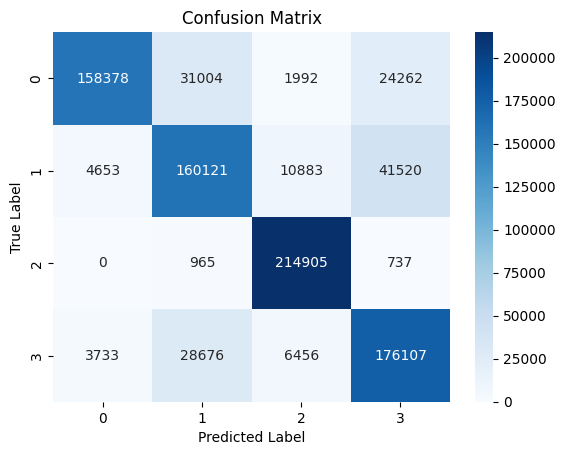

In [114]:
import matplotlib.pyplot as plt
import seaborn as sns
# Step 9: Plot the confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [115]:
# For MinMaxScaler unscaling
columns_minmax = ['energy', 'r', 'time']  # Columns you scaled with MinMaxScaler
X1_test_unscaled_minmax = minmax_unscaler(fes.X, X1_test.copy(), columns_minmax)

In [116]:
# For RobustScaler unscaling
columns_robust = ['z']  # Columns you scaled with RobustScaler
X1_test_unscaled_robust = robust_unscaler(fes.X, X1_test.copy(), columns_robust)


In [117]:
# Reset the index of each DataFrame
X1_test_unscaled_minmax = X1_test_unscaled_minmax.reset_index(drop=True)
X1_test_unscaled_robust = X1_test_unscaled_robust.reset_index(drop=True)
X1_test= X1_test.reset_index(drop=True)

# Now concatenate the DataFrames with 'phi' between 'z' and 'time'
combined_df1 = pd.concat([
    X1_test_unscaled_minmax[['energy', 'r']],  # Columns from MinMax unscaled data
    X1_test_unscaled_robust[['z']],  # 'z' from Robust unscaled data
    X1_test[['phi']],  # Insert 'phi' here
    X1_test_unscaled_robust[['time']]  # 'time' from Robust unscaled data
], axis=1)

In [118]:
signal_detection_metrics(y1_test, y1_pred, [1,2])


Results for class 1:
  - Total events classified as this class: 220766
  - Percentage of actual signal events detected: 73.73%
  - Percentage of detected signal accuracy: 72.53%
  - Misclassified as other classes:
    - Class 0.0: 14.04%
    - Class 3.0: 12.99%
    - Class 2.0: 0.44%

Results for class 2:
  - Total events classified as this class: 234236
  - Percentage of actual signal events detected: 99.21%
  - Percentage of detected signal accuracy: 91.75%
  - Misclassified as other classes:
    - Class 1.0: 4.65%
    - Class 3.0: 2.76%
    - Class 0.0: 0.85%


{1: {'Total events classified as this class': 220766,
  'Percentage of actual signal events detected': 73.72834139895107,
  'Percentage of detected signal accuracy': 72.52973736897891,
  'Misclassification breakdown (%)': {0.0: 14.043829212831685,
   3.0: 12.989319007455858,
   2.0: 0.43711441073353685}},
 2: {'Total events classified as this class': 234236,
  'Percentage of actual signal events detected': 99.21424515366539,
  'Percentage of detected signal accuracy': 91.74721221332331,
  'Misclassification breakdown (%)': {1.0: 4.646168821188886,
   3.0: 2.756194607148346,
   0.0: 0.8504243583394525}}}

In [119]:
# Set the save directory before the function
save_dir = "../plots/ANN_sep_chain/214/"

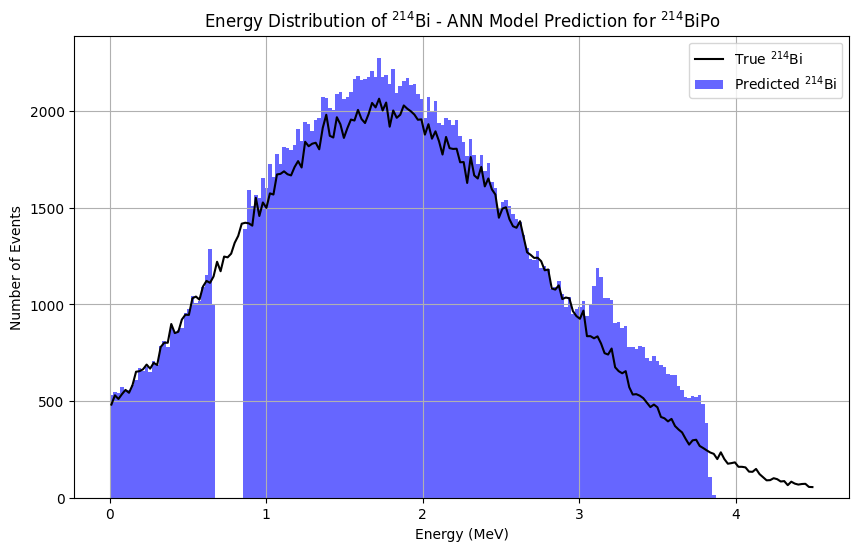

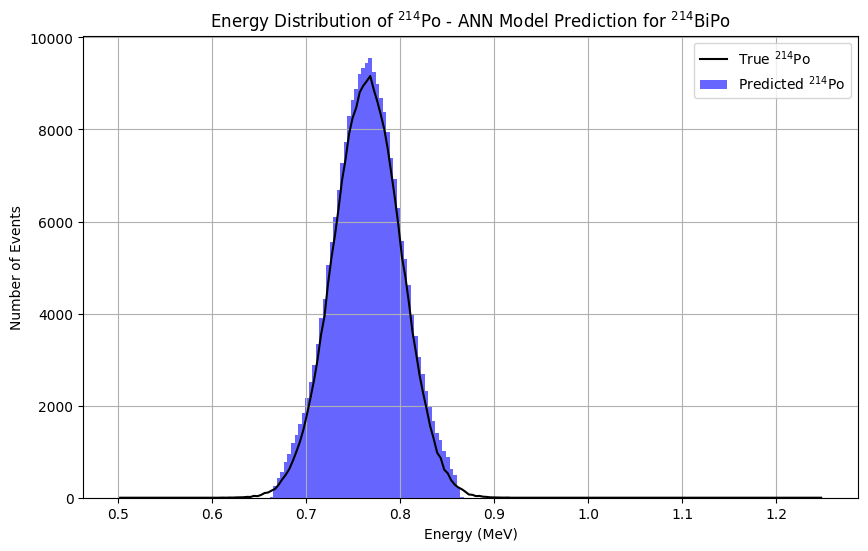

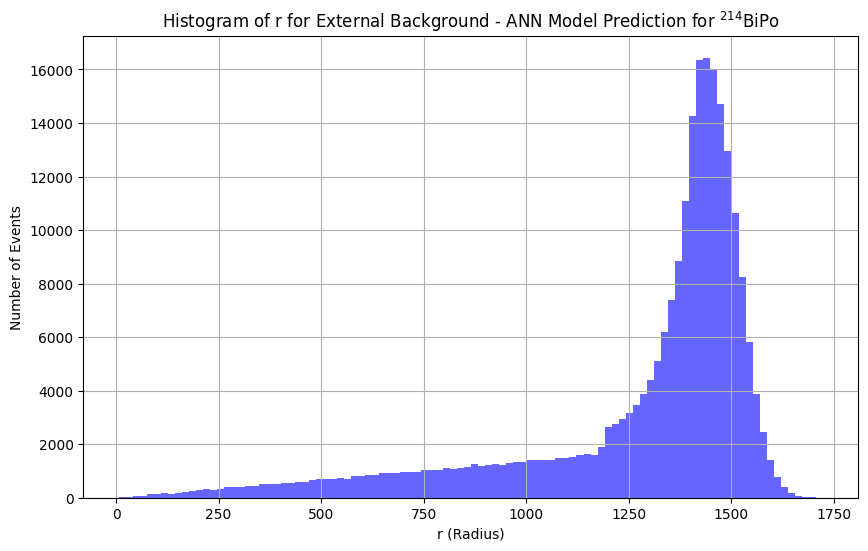

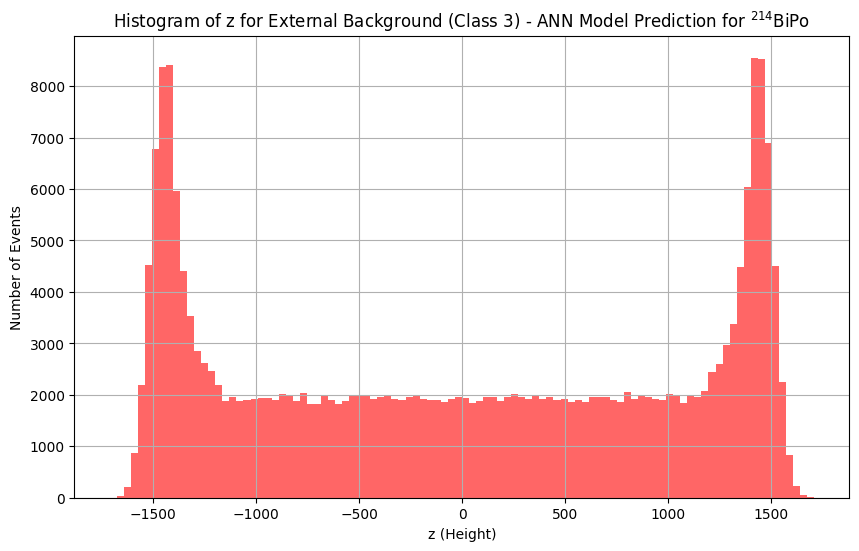

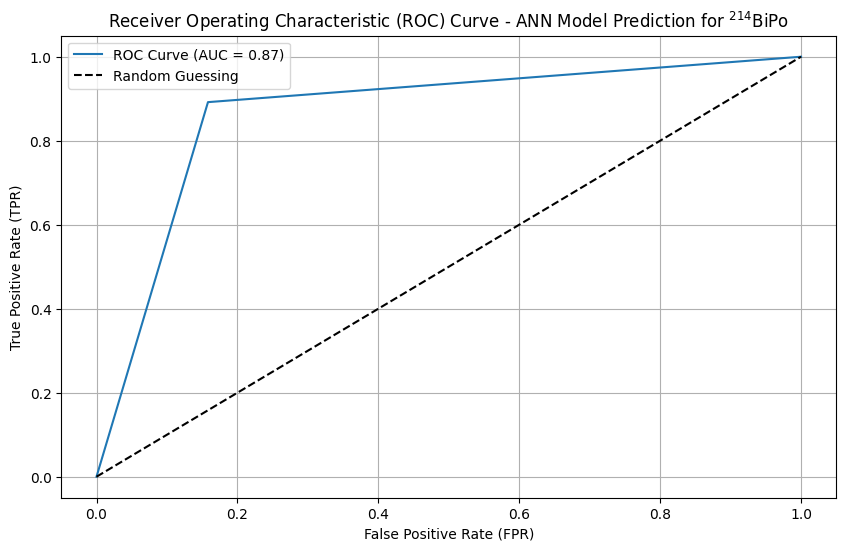

In [120]:
# Call the function and pass save_dir
plot_event_analysis(combined_df1, y1_pred, y1_test, model_name=r"ANN Model Prediction for $^{214}$BiPo", save_dir=save_dir, event_types=[1, 2], save_plots=True)

In [121]:
model_name = r"ANN Model Prediction for $^{214}$BiPo"
save_plots = True  # Set to False if you don't want to save plots

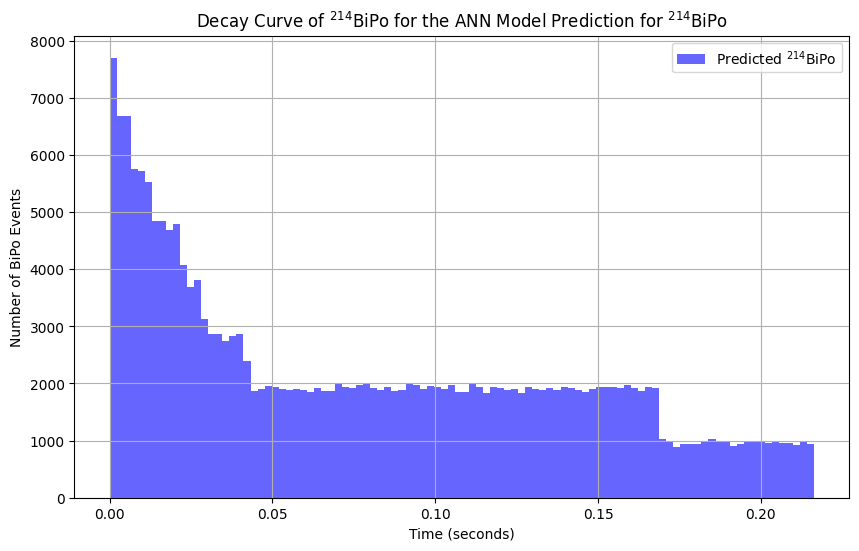

In [122]:
# Calculate time differences for Bi214 → Po214
time_diffs_bi_po214 = calculate_time_differences(X1_test, y1_pred, 1, 2)

# Plot decay curve for Bi214 → Po214
plot_decay_curve(time_diffs_bi_po214, r"$^{214}$BiPo", model_name, save_dir, save_plots)

In [123]:
# Plot zoomed-in decay curve for Bi214 → Po214 (example: xlim from 0 to 0.001 sec)
#plot_decay_curve(time_diffs_bi_po214, "Bi214 → Po214", model_name, save_dir, save_plots, xlim=(0, 0.001))

## Model 214 (Whole Chain)

In [124]:
X = fes.X_scaled
y =fes.y

In [125]:
scaler = MinMaxScaler()
X.loc[:, 'time'] = scaler.fit_transform(X[['time']])  # Normalize safely

In [126]:
# Further split using train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [127]:
# Step 3: Predict probabilities on the unseen data
y_prob_214 = model_1_2.predict(X_test)  # Probabilities for [0, 1, 2, 3]

40269/40269 [==============================] - 91s 2ms/step


In [128]:
from sklearn.metrics import confusion_matrix, classification_report

In [129]:
# Convert probabilities to class labels using argmax
y_pred_214 = np.argmax(y_prob_214, axis=1)

In [130]:
# Step 7: Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred_214)

In [131]:
# Step 8: Print the classification report (precision, recall, F1-score)
print("Classification Report:")
print(classification_report(y_test, y_pred_214))

Classification Report:


/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

         0.0       0.95      0.74      0.83    215377
         1.0       0.34      0.74      0.47    217573
         2.0       0.66      0.99      0.79    216543
         3.0       0.55      0.82      0.66    215634
         4.0       0.00      0.00      0.00    211648
         5.0       0.00      0.00      0.00    211832

    accuracy                           0.55   1288607
   macro avg       0.42      0.55      0.46   1288607
weighted avg       0.42      0.55      0.46   1288607



/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


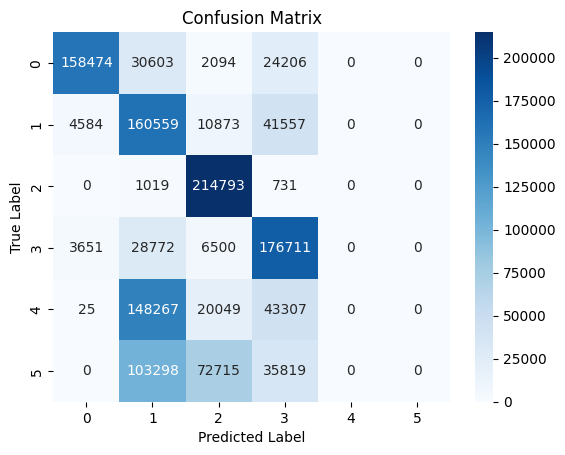

In [132]:
import matplotlib.pyplot as plt
import seaborn as sns
# Step 9: Plot the confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [133]:
# For MinMaxScaler unscaling
columns_minmax = ['energy', 'r', 'time']  # Columns you scaled with MinMaxScaler
X_test_unscaled_minmax_214 = minmax_unscaler(fes.X, X_test.copy(), columns_minmax)

In [134]:
# For RobustScaler unscaling
columns_robust = ['z']  # Columns you scaled with RobustScaler
X_test_unscaled_robust_214 = robust_unscaler(fes.X, X_test.copy(), columns_robust)


In [135]:
# Reset the index of each DataFrame
X_test_unscaled_minmax_214 = X_test_unscaled_minmax_214.reset_index(drop=True)
X_test_unscaled_robust_214 = X_test_unscaled_robust_214.reset_index(drop=True)
X_test= X_test.reset_index(drop=True)

# Now concatenate the DataFrames with 'phi' between 'z' and 'time'
combined_df_214 = pd.concat([
    X_test_unscaled_minmax_214[['energy', 'r']],  # Columns from MinMax unscaled data
    X_test_unscaled_robust_214[['z']],  # 'z' from Robust unscaled data
    X_test[['phi']],  # Insert 'phi' here
    X_test_unscaled_robust_214[['time']]  # 'time' from Robust unscaled data
], axis=1)

In [136]:
signal_detection_metrics(y_test, y_pred_214, [1,2])


Results for class 1:
  - Total events classified as this class: 472518
  - Percentage of actual signal events detected: 73.80%
  - Percentage of detected signal accuracy: 33.98%
  - Misclassified as other classes:
    - Class 4.0: 31.38%
    - Class 5.0: 21.86%
    - Class 0.0: 6.48%
    - Class 3.0: 6.09%
    - Class 2.0: 0.22%

Results for class 2:
  - Total events classified as this class: 327024
  - Percentage of actual signal events detected: 99.19%
  - Percentage of detected signal accuracy: 65.68%
  - Misclassified as other classes:
    - Class 5.0: 22.24%
    - Class 4.0: 6.13%
    - Class 3.0: 1.99%
    - Class 1.0: 3.32%
    - Class 0.0: 0.64%


{1: {'Total events classified as this class': 472518,
  'Percentage of actual signal events detected': 73.79546175306679,
  'Percentage of detected signal accuracy': 33.979446285644144,
  'Misclassification breakdown (%)': {4.0: 31.378063904443852,
   5.0: 21.86117777523819,
   0.0: 6.47657867001892,
   3.0: 6.089080204352004,
   2.0: 0.21565316030288792}},
 2: {'Total events classified as this class': 327024,
  'Percentage of actual signal events detected': 99.19184642311227,
  'Percentage of detected signal accuracy': 65.68111208963256,
  'Misclassification breakdown (%)': {5.0: 22.23537110426146,
   4.0: 6.130742697783649,
   3.0: 1.9876217036058514,
   1.0: 3.3248324282009882,
   0.0: 0.6403199765154851}}}

In [137]:
# Set the save directory before the function
save_dir = "../plots/ANN_sep_chain/214_whole/"

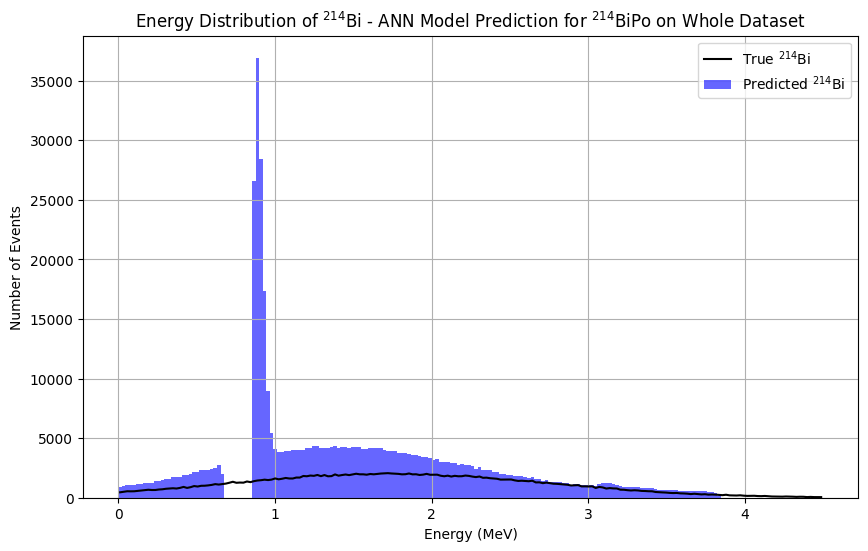

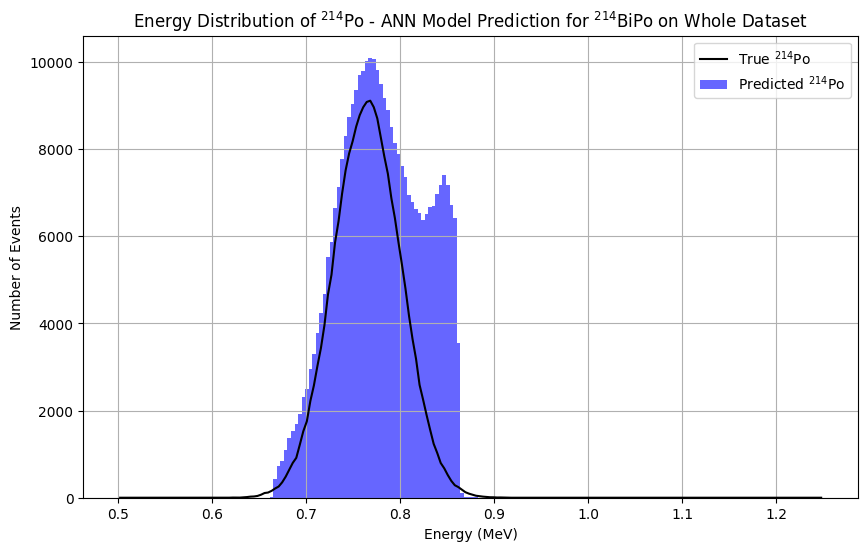

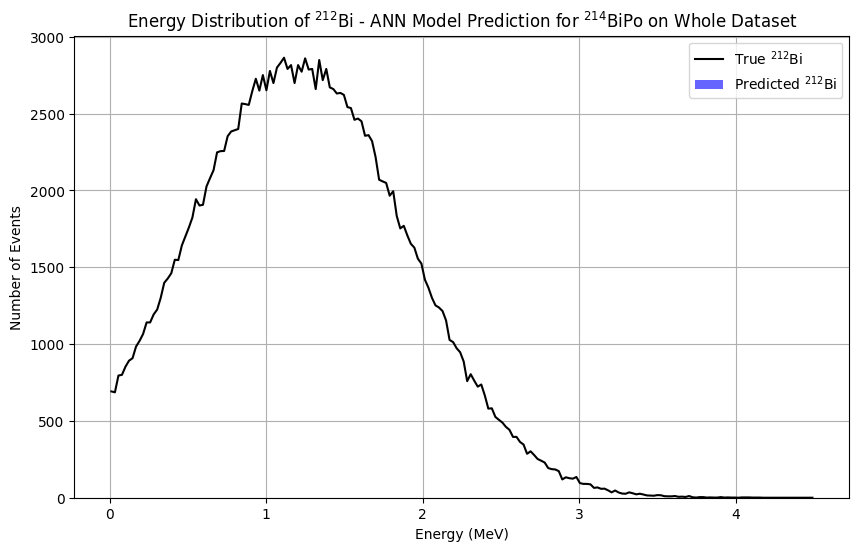

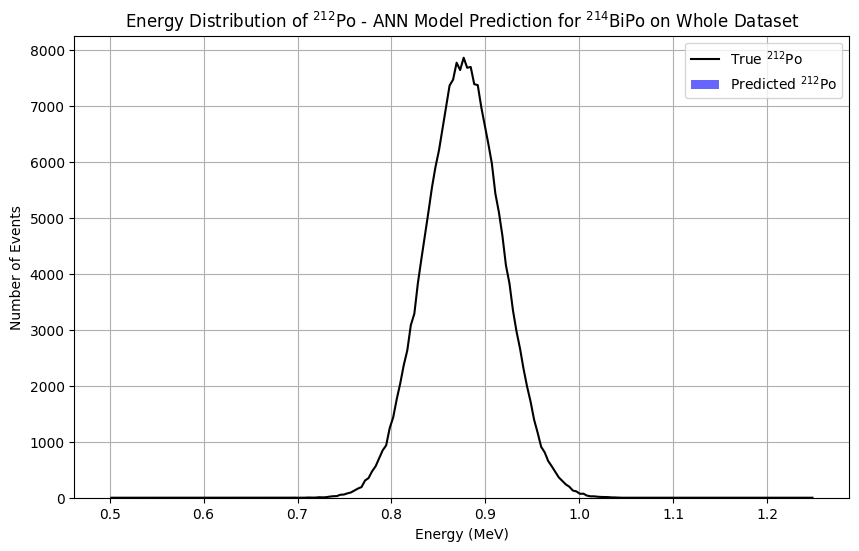

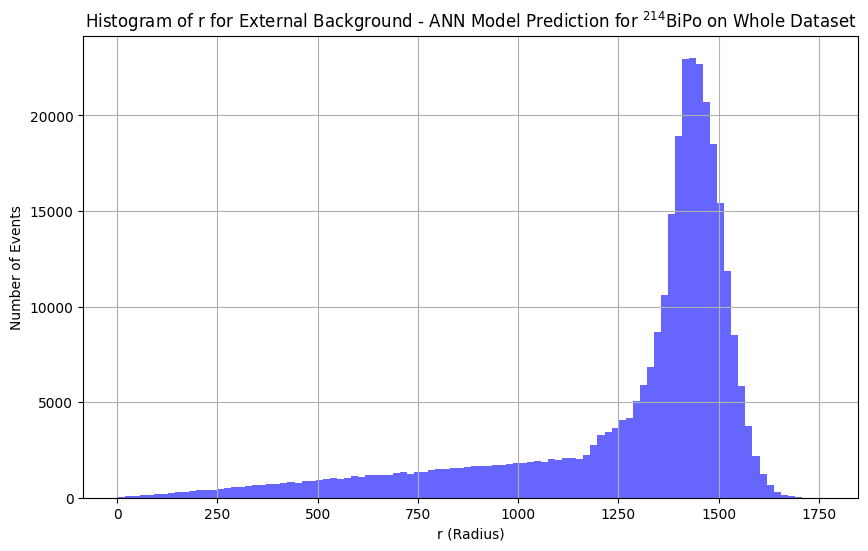

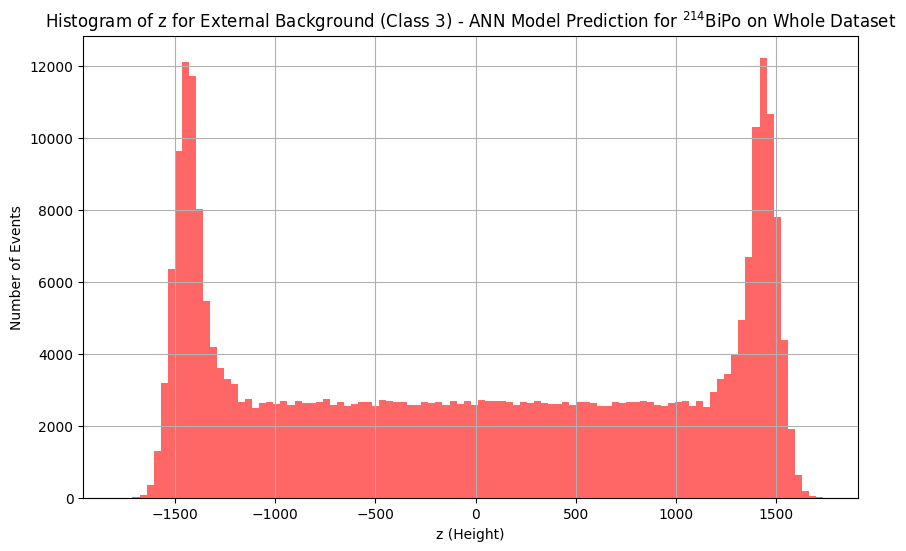

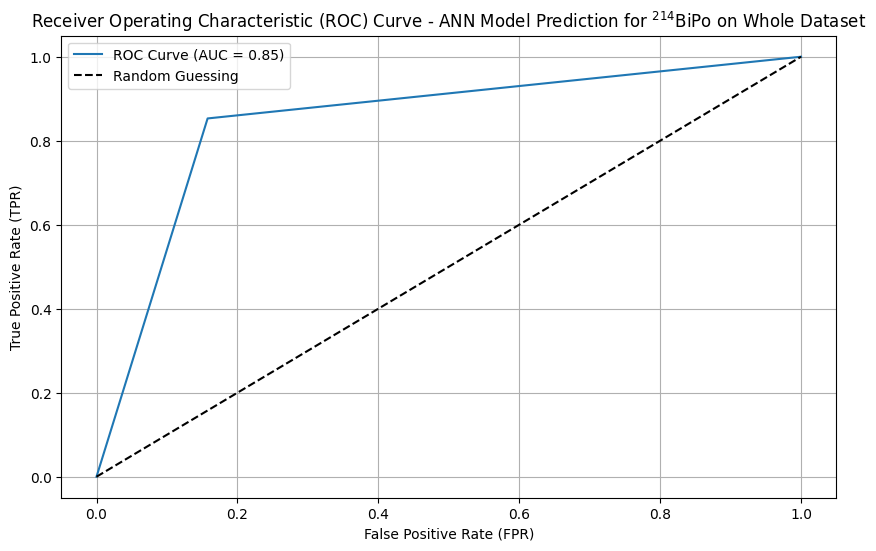

In [138]:
# Call the function and pass save_dir
plot_event_analysis(combined_df_214, y_pred_214, y_test, model_name=r"ANN Model Prediction for $^{214}$BiPo on Whole Dataset", save_dir=save_dir, event_types=[1, 2, 4, 5], save_plots=True)

## Model 212 (Individual)

In [139]:
X2 = fes.X2
y2 =fes.y2

In [140]:
scaler = MinMaxScaler()
X2.loc[:, 'time'] = scaler.fit_transform(X2[['time']])  # Normalize safely

In [141]:
# Further split using train_test_split
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=0)

In [142]:
# Step 3: Predict probabilities on the unseen data
y2_pred = model_4_5.predict(X2_test)  # Probabilities for [0, 1, 2, 3]

26732/26732 [==============================] - 60s 2ms/step


In [143]:
from sklearn.metrics import confusion_matrix, classification_report

In [144]:
# Convert probabilities to class labels using argmax
y2_pred = np.argmax(y2_pred, axis=1)

In [145]:
# Step 7: Compute the confusion matrix
cm = confusion_matrix(y2_test, y2_pred)

In [146]:
# Step 8: Print the classification report (precision, recall, F1-score)
print("Classification Report:")
print(classification_report(y2_test, y2_pred))

Classification Report:
              precision    recall  f1-score   support

         0.0       0.96      0.78      0.86    215594
         3.0       0.75      0.80      0.77    215577
         4.0       0.74      0.73      0.73    212143
         5.0       0.87      0.98      0.92    212101

    accuracy                           0.82    855415
   macro avg       0.83      0.82      0.82    855415
weighted avg       0.83      0.82      0.82    855415



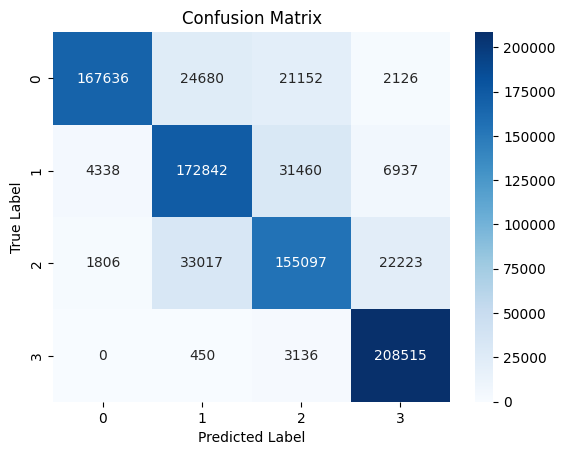

In [147]:
import matplotlib.pyplot as plt
import seaborn as sns
# Step 9: Plot the confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [148]:
# For MinMaxScaler unscaling
columns_minmax = ['energy', 'r', 'time']  # Columns you scaled with MinMaxScaler
X2_test_unscaled_minmax = minmax_unscaler(fes.X, X2_test.copy(), columns_minmax)

In [149]:

# For RobustScaler unscaling
columns_robust = ['z']  # Columns you scaled with RobustScaler
X2_test_unscaled_robust = robust_unscaler(fes.X, X2_test.copy(), columns_robust)


In [150]:
# Reset the index of each DataFrame
X2_test_unscaled_minmax = X2_test_unscaled_minmax.reset_index(drop=True)
X2_test_unscaled_robust = X2_test_unscaled_robust.reset_index(drop=True)
X2_test= X2_test.reset_index(drop=True)

# Now concatenate the DataFrames with 'phi' between 'z' and 'time'
combined_df2 = pd.concat([
    X2_test_unscaled_minmax[['energy', 'r']],  # Columns from MinMax unscaled data
    X2_test_unscaled_robust[['z']],  # 'z' from Robust unscaled data
    X2_test[['phi']],  # Insert 'phi' here
    X2_test_unscaled_robust[['time']]  # 'time' from Robust unscaled data
], axis=1)

In [151]:
signal_detection_metrics(y2_test, y2_pred, [4,5])


Results for class 4:
  - Total events classified as this class: 210845
  - Percentage of actual signal events detected: 73.11%
  - Percentage of detected signal accuracy: 73.56%
  - Misclassified as other classes:
    - Class 3.0: 14.92%
    - Class 0.0: 10.03%
    - Class 5.0: 1.49%

Results for class 5:
  - Total events classified as this class: 239801
  - Percentage of actual signal events detected: 98.31%
  - Percentage of detected signal accuracy: 86.95%
  - Misclassified as other classes:
    - Class 3.0: 2.89%
    - Class 4.0: 9.27%
    - Class 0.0: 0.89%


{4: {'Total events classified as this class': 210845,
  'Percentage of actual signal events detected': 73.10964773761096,
  'Percentage of detected signal accuracy': 73.55972396784368,
  'Misclassification breakdown (%)': {3.0: 14.920913467238966,
   0.0: 10.032014038748844,
   5.0: 1.4873485261685124}},
 5: {'Total events classified as this class': 239801,
  'Percentage of actual signal events detected': 98.30929604292294,
  'Percentage of detected signal accuracy': 86.95334881839526,
  'Misclassification breakdown (%)': {3.0: 2.8928152926801807,
   4.0: 9.267267442587812,
   0.0: 0.8865684463367542}}}

In [152]:
# Set the save directory before the function
save_dir = "../plots/ANN_sep_chain/212/"

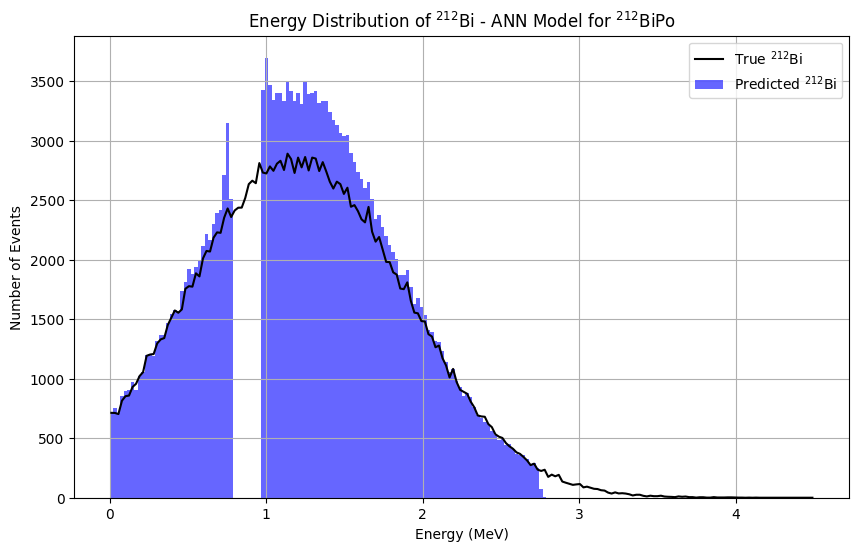

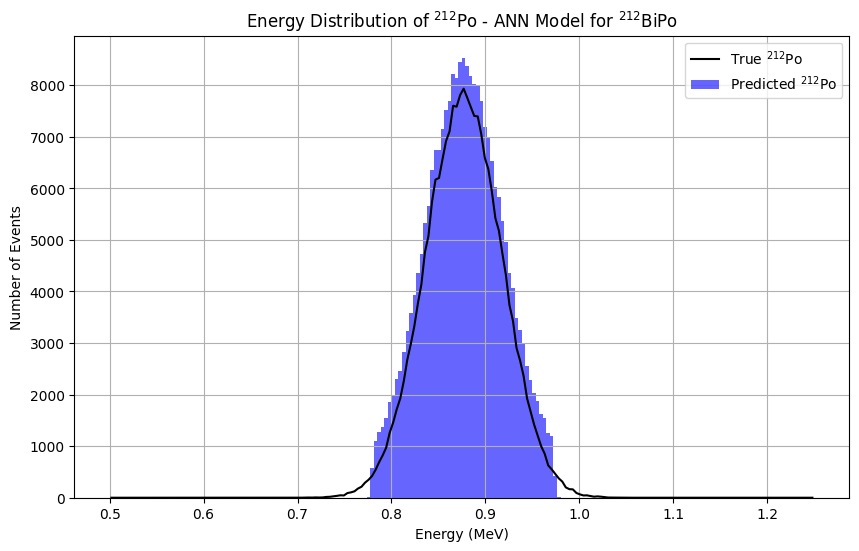

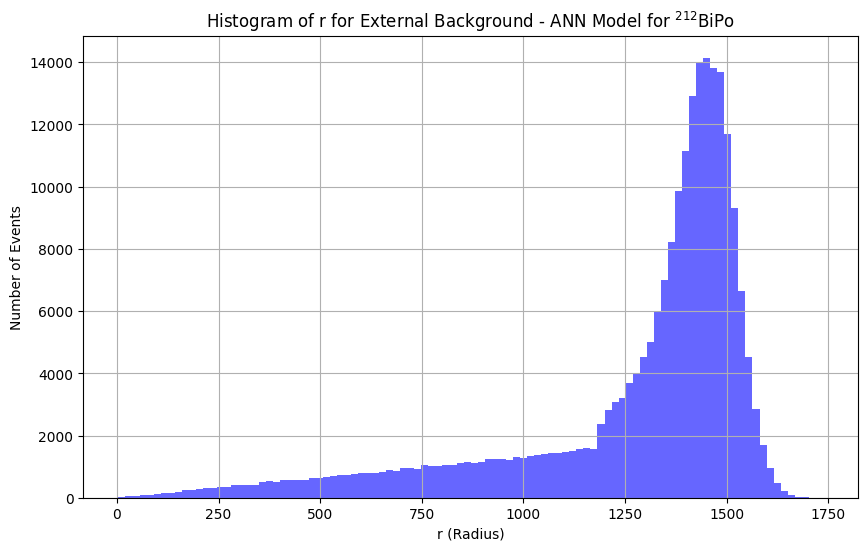

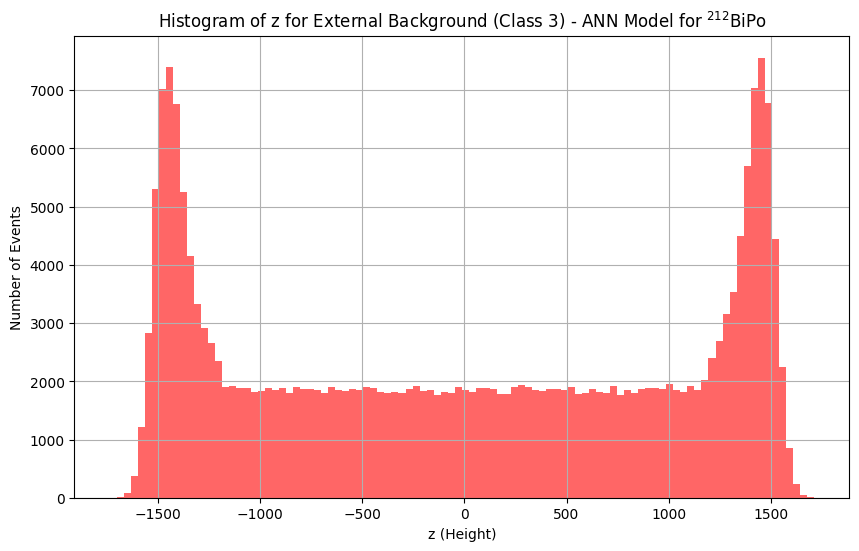

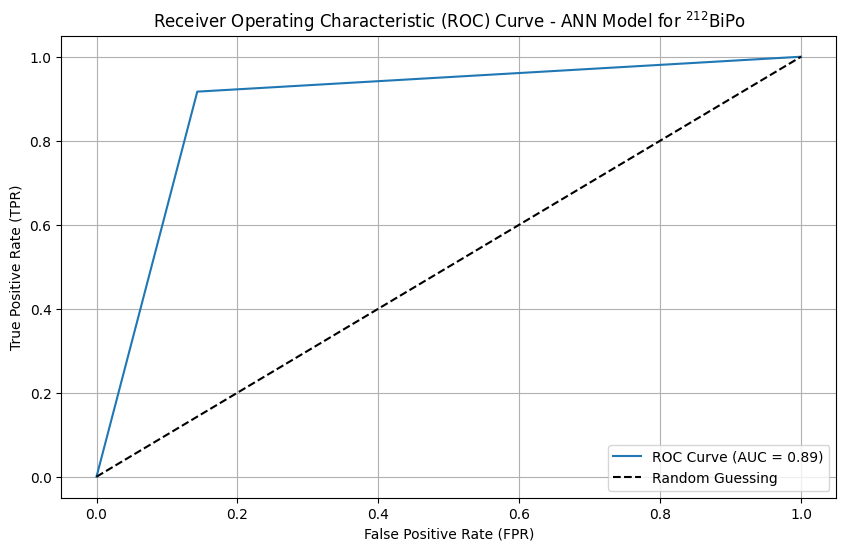

In [153]:
# Call the function and pass save_dir
plot_event_analysis(combined_df2, y2_pred, y2_test, model_name=r"ANN Model for $^{212}$BiPo", save_dir=save_dir, event_types=[ 4, 5], save_plots=True)

In [154]:
model_name = r"ANN Model for $^{212}$BiPo"
save_plots = True  # Set to False if you don't want to save plots

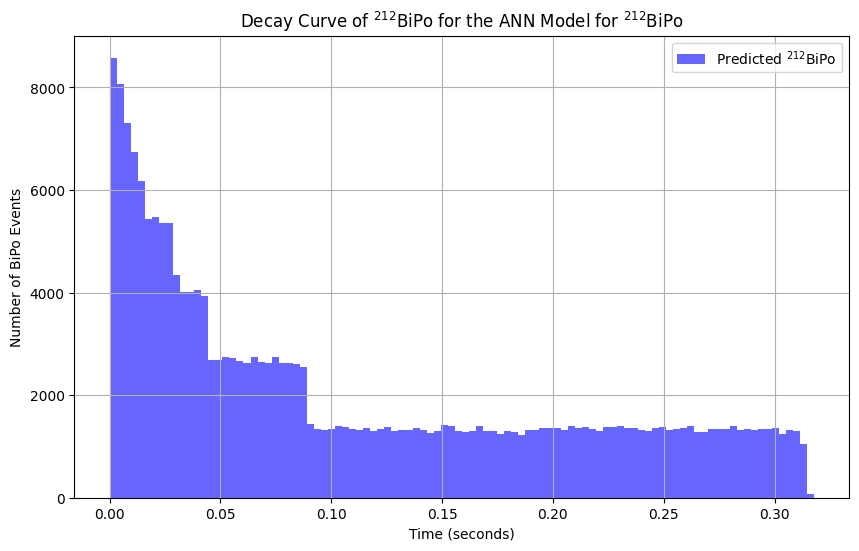

In [155]:
# Calculate time differences for Bi212 → Po212
time_diffs_bi_po212 = calculate_time_differences(X2_test, y2_pred, 4, 5)

# Plot decay curve for Bi212 → Po212
plot_decay_curve(time_diffs_bi_po212, r"$^{212}$BiPo", model_name, save_dir, save_plots)

In [156]:
# Plot zoomed-in decay curve for Bi212 → Po212
#plot_decay_curve(time_diffs_bi_po212, "Bi212 → Po212", model_name, save_dir, save_plots, xlim=(0, 0.001))

## Model 212 (Whole Chain)

In [157]:
# Step 3: Predict probabilities on the unseen data
y_prob_212 = model_4_5.predict(X_test)  # Probabilities for [0, 1, 2, 3]

40269/40269 [==============================] - 73s 2ms/step


In [158]:
from sklearn.metrics import confusion_matrix, classification_report

In [159]:
# Convert probabilities to class labels using argmax
y_pred_212 = np.argmax(y_prob_212, axis=1)

In [160]:
# Step 7: Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred_212)

In [161]:
# Step 8: Print the classification report (precision, recall, F1-score)
print("Classification Report:")
print(classification_report(y_test, y_pred_212))

Classification Report:


/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

         0.0       0.83      0.78      0.80    215377
         1.0       0.00      0.00      0.00    217573
         2.0       0.00      0.00      0.00    216543
         3.0       0.58      0.80      0.67    215634
         4.0       0.33      0.73      0.46    211648
         5.0       0.64      0.98      0.77    211832

    accuracy                           0.55   1288607
   macro avg       0.40      0.55      0.45   1288607
weighted avg       0.40      0.55      0.45   1288607



/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


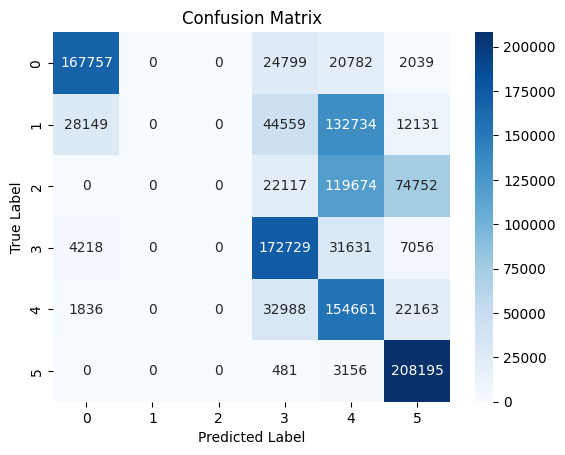

In [162]:
import matplotlib.pyplot as plt
import seaborn as sns
# Step 9: Plot the confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [163]:
# For MinMaxScaler unscaling
columns_minmax = ['energy', 'r', 'time']  # Columns you scaled with MinMaxScaler
X_test_unscaled_minmax_212 = minmax_unscaler(fes.X, X_test.copy(), columns_minmax)

In [164]:
# For RobustScaler unscaling
columns_robust = ['z']  # Columns you scaled with RobustScaler
X_test_unscaled_robust_212 = robust_unscaler(fes.X, X_test.copy(), columns_robust)


In [165]:
# Reset the index of each DataFrame
X_test_unscaled_minmax_212 = X_test_unscaled_minmax_212.reset_index(drop=True)
X_test_unscaled_robust_212 = X_test_unscaled_robust_212.reset_index(drop=True)
X_test= X_test.reset_index(drop=True)

# Now concatenate the DataFrames with 'phi' between 'z' and 'time'
combined_df_212 = pd.concat([
    X_test_unscaled_minmax_212[['energy', 'r']],  # Columns from MinMax unscaled data
    X_test_unscaled_robust_212[['z']],  # 'z' from Robust unscaled data
    X_test[['phi']],  # Insert 'phi' here
    X_test_unscaled_robust_212[['time']]  # 'time' from Robust unscaled data
], axis=1)

In [166]:
signal_detection_metrics(y_test, y_pred_212, [4,5])


Results for class 4:
  - Total events classified as this class: 462638
  - Percentage of actual signal events detected: 73.07%
  - Percentage of detected signal accuracy: 33.43%
  - Misclassified as other classes:
    - Class 1.0: 28.69%
    - Class 0.0: 4.49%
    - Class 2.0: 25.87%
    - Class 3.0: 6.84%
    - Class 5.0: 0.68%

Results for class 5:
  - Total events classified as this class: 326336
  - Percentage of actual signal events detected: 98.28%
  - Percentage of detected signal accuracy: 63.80%
  - Misclassified as other classes:
    - Class 1.0: 3.72%
    - Class 4.0: 6.79%
    - Class 2.0: 22.91%
    - Class 3.0: 2.16%
    - Class 0.0: 0.62%


{4: {'Total events classified as this class': 462638,
  'Percentage of actual signal events detected': 73.07463335349259,
  'Percentage of detected signal accuracy': 33.43024135501191,
  'Misclassification breakdown (%)': {1.0: 28.690682563905256,
   0.0: 4.492065070314155,
   2.0: 25.86774108482226,
   3.0: 6.837095093788231,
   5.0: 0.6821748321581885}},
 5: {'Total events classified as this class': 326336,
  'Percentage of actual signal events detected': 98.28307337890404,
  'Percentage of detected signal accuracy': 63.79774220435379,
  'Misclassification breakdown (%)': {1.0: 3.717334281231614,
   4.0: 6.791466464012553,
   2.0: 22.906452245538343,
   3.0: 2.1621886644440087,
   0.0: 0.6248161404196901}}}

In [167]:
# Set the save directory before the function
save_dir = "../plots/ANN_sep_chain/212_whole/"

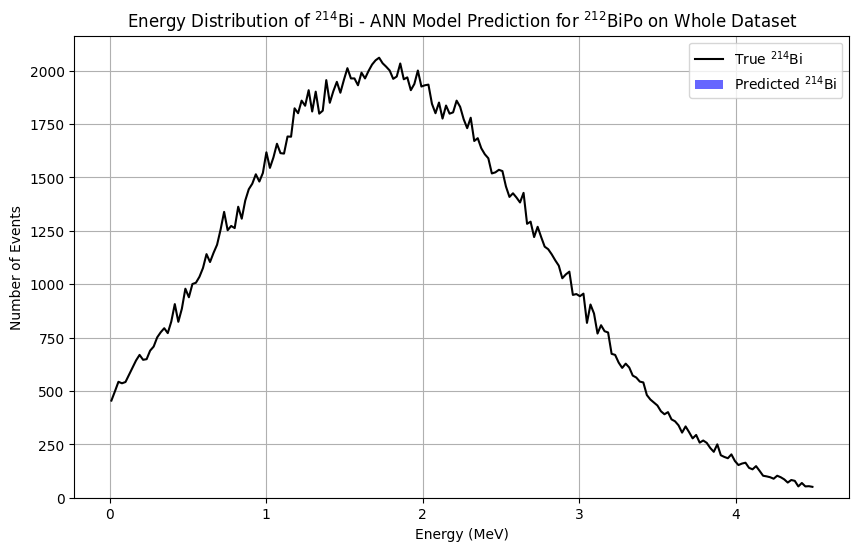

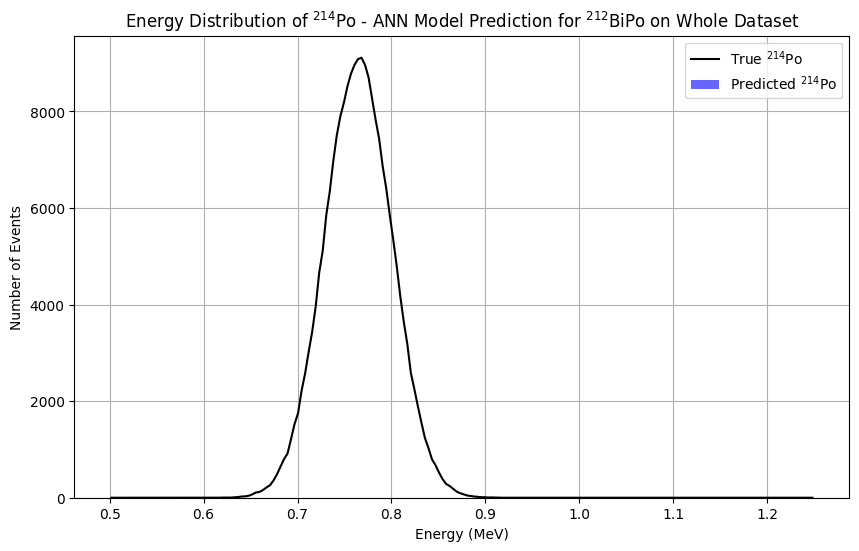

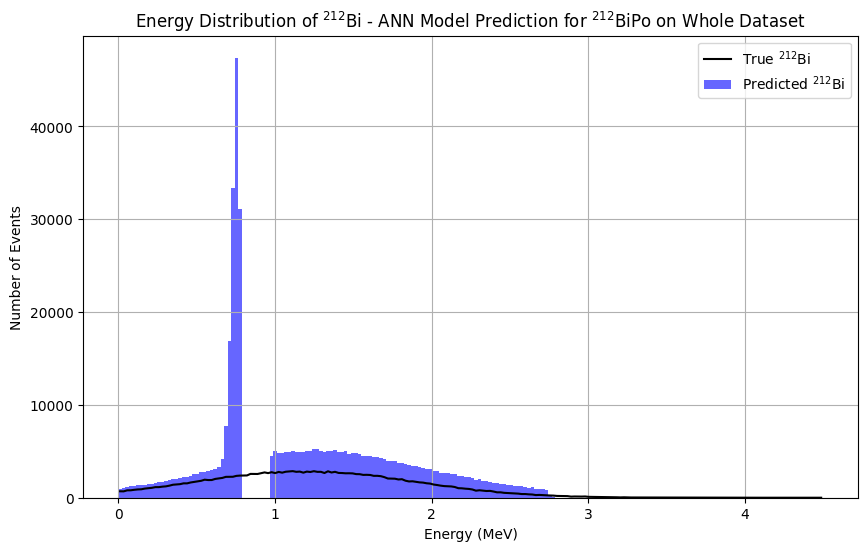

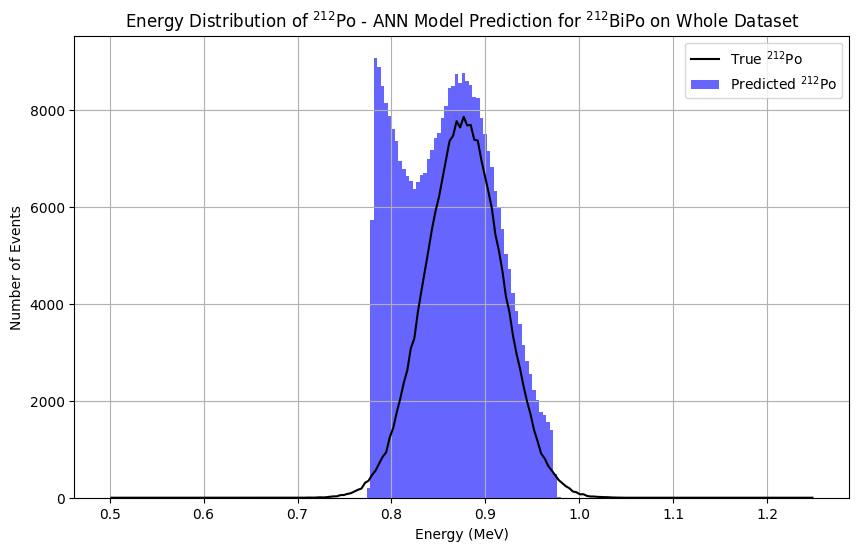

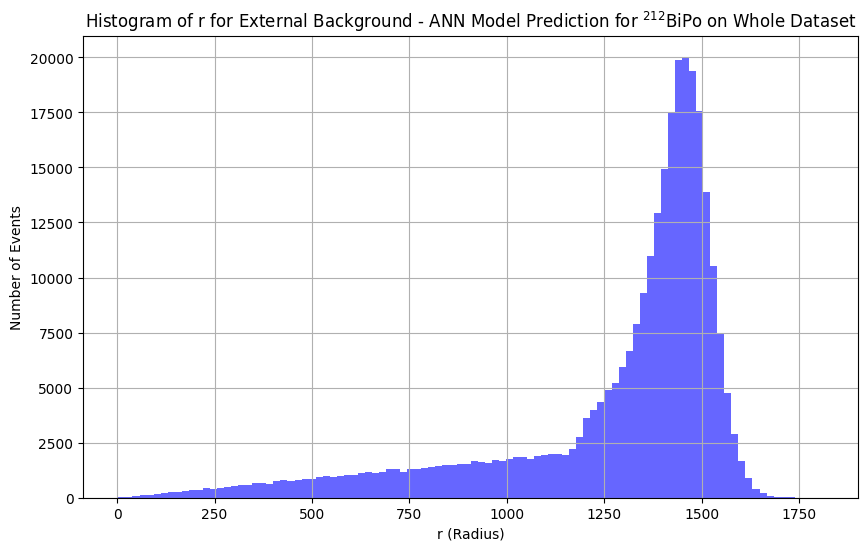

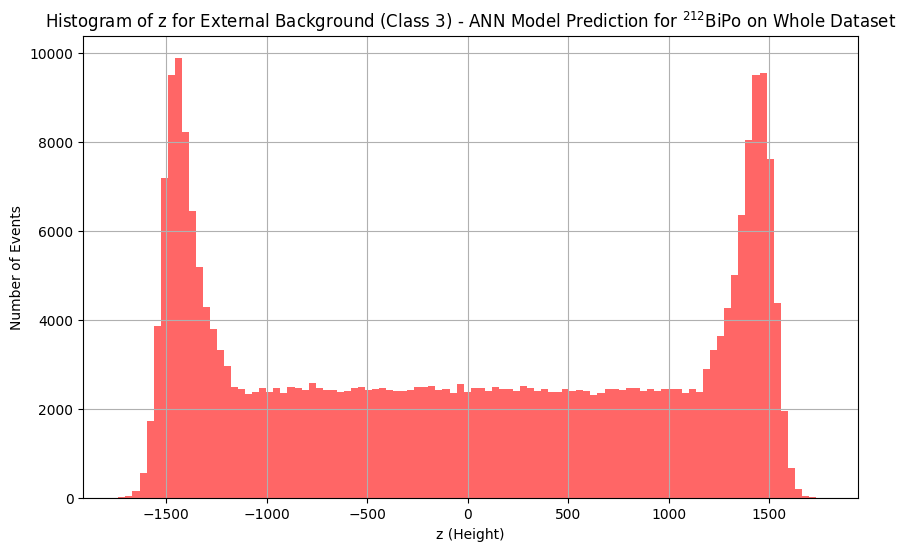

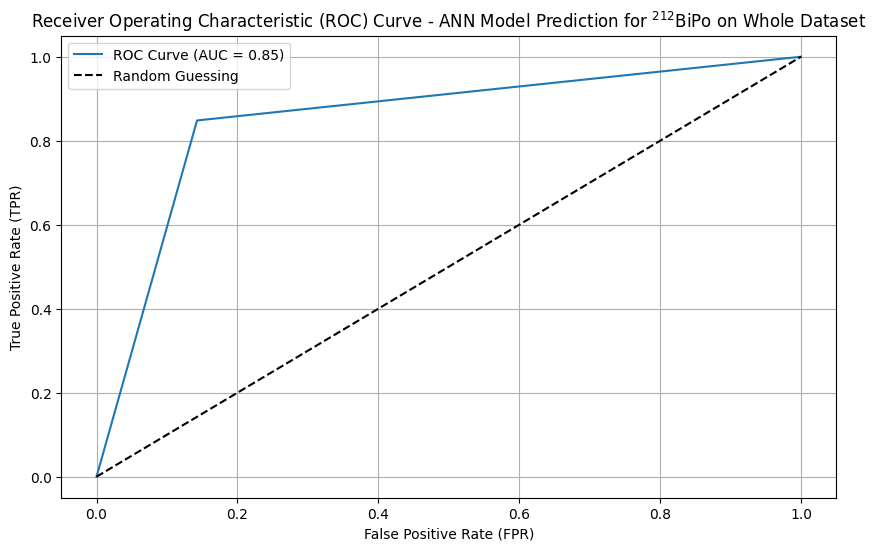

In [168]:
# Call the function and pass save_dir
plot_event_analysis(combined_df_212, y_pred_212, y_test, model_name=r"ANN Model Prediction for $^{212}$BiPo on Whole Dataset", save_dir=save_dir, event_types=[1, 2, 4, 5], save_plots=True)

# Combined

In [169]:
# Step 4: Define the conflict resolution function (Maximum Likelihood Estimation)
def resolve_conflict(model1_probs, model2_probs):
    final_prediction = np.zeros_like(model1_probs)
    
    for i in range(len(model1_probs)):
        # Get the predicted class and probability for both models
        model1_pred = np.argmax(model1_probs[i])  # Model 1's predicted class
        model1_prob = model1_probs[i][model1_pred]  # Model 1's probability for the predicted class
        
        model2_pred = np.argmax(model2_probs[i])  # Model 2's predicted class
        model2_prob = model2_probs[i][model2_pred]  # Model 2's probability for the predicted class
        
        # If both models agree on the class (class 0 or 3)
        if model1_pred == 0 or model2_pred == 0:
            final_prediction[i] = 0
        elif model1_pred == 3 or model2_pred == 3:
            final_prediction[i] = 3
        else:
            # Resolve conflict between models when they predict different classes
            if model1_pred in [1, 2] and model2_pred in [4, 5]:
                # Choose the model with the higher confidence (probability)
                if model1_prob > model2_prob:
                    final_prediction[i] = model1_pred  # Prefer Model 1's prediction
                else:
                    final_prediction[i] = model2_pred  # Prefer Model 2's prediction
            elif model1_pred in [1, 2]:
                final_prediction[i] = model1_pred  # Use Model 1's prediction for 1 or 2
            elif model2_pred in [4, 5]:
                final_prediction[i] = model2_pred  # Use Model 2's prediction for 4 or 5
    
    return final_prediction


In [170]:
# Step 5: Resolve conflicts and get final predictions
final_preds = resolve_conflict(y_prob_214, y_prob_212)

In [171]:
y_pred = final_preds[:, 0]

In [172]:
print(y_pred)

[0. 1. 5. ... 3. 5. 0.]


In [173]:
from sklearn.metrics import confusion_matrix, classification_report

In [174]:
# Step 7: Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)

In [175]:
# Step 8: Print the classification report (precision, recall, F1-score)
print("Classification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

         0.0       0.83      0.78      0.80    215377
         1.0       0.48      0.24      0.32    217573
         2.0       0.80      0.83      0.81    216543
         3.0       0.50      0.86      0.63    215634
         4.0       0.51      0.48      0.49    211648
         5.0       0.83      0.69      0.75    211832

    accuracy                           0.65   1288607
   macro avg       0.66      0.65      0.64   1288607
weighted avg       0.66      0.65      0.64   1288607



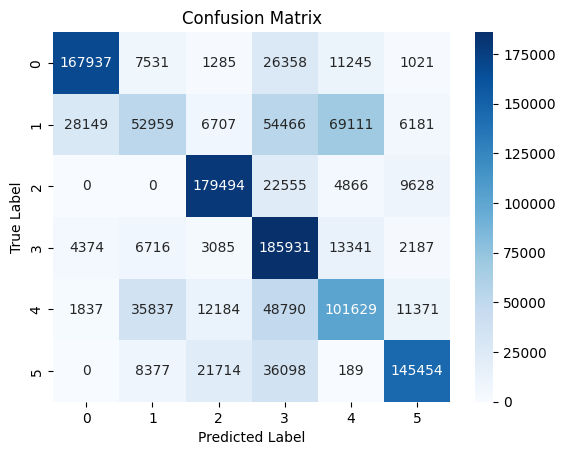

In [176]:
import matplotlib.pyplot as plt
import seaborn as sns
# Step 9: Plot the confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [177]:
# For MinMaxScaler unscaling
columns_minmax = ['energy', 'r', 'time']  # Columns you scaled with MinMaxScaler
X_test_unscaled_minmax = minmax_unscaler(fes.X, X_test.copy(), columns_minmax)


In [178]:

# For RobustScaler unscaling
columns_robust = ['z']  # Columns you scaled with RobustScaler
X_test_unscaled_robust = robust_unscaler(fes.X, X_test.copy(), columns_robust)


In [179]:
# Reset the index of each DataFrame
X_test_unscaled_minmax = X_test_unscaled_minmax.reset_index(drop=True)
X_test_unscaled_robust = X_test_unscaled_robust.reset_index(drop=True)
X_test= X_test.reset_index(drop=True)

# Now concatenate the DataFrames with 'phi' between 'z' and 'time'
combined_df = pd.concat([
    X_test_unscaled_minmax[['energy', 'r']],  # Columns from MinMax unscaled data
    X_test_unscaled_robust[['z']],  # 'z' from Robust unscaled data
    X_test[['phi']],  # Insert 'phi' here
    X_test_unscaled_robust[['time']]  # 'time' from Robust unscaled data
], axis=1)

In [180]:
signal_detection_metrics(y_test, y_pred, [1,2,4,5])


Results for class 1:
  - Total events classified as this class: 111420
  - Percentage of actual signal events detected: 24.34%
  - Percentage of detected signal accuracy: 47.53%
  - Misclassified as other classes:
    - Class 4.0: 32.16%
    - Class 5.0: 7.52%
    - Class 3.0: 6.03%
    - Class 0.0: 6.76%

Results for class 2:
  - Total events classified as this class: 224469
  - Percentage of actual signal events detected: 82.89%
  - Percentage of detected signal accuracy: 79.96%
  - Misclassified as other classes:
    - Class 5.0: 9.67%
    - Class 4.0: 5.43%
    - Class 3.0: 1.37%
    - Class 1.0: 2.99%
    - Class 0.0: 0.57%

Results for class 4:
  - Total events classified as this class: 200381
  - Percentage of actual signal events detected: 48.02%
  - Percentage of detected signal accuracy: 50.72%
  - Misclassified as other classes:
    - Class 1.0: 34.49%
    - Class 0.0: 5.61%
    - Class 3.0: 6.66%
    - Class 2.0: 2.43%
    - Class 5.0: 0.09%

Results for class 5:
  - Total

{1: {'Total events classified as this class': 111420,
  'Percentage of actual signal events detected': 24.340795962734347,
  'Percentage of detected signal accuracy': 47.53096392030156,
  'Misclassification breakdown (%)': {4.0: 32.16388440136421,
   5.0: 7.518398851193682,
   3.0: 6.027643152037336,
   0.0: 6.759109675103213}},
 2: {'Total events classified as this class': 224469,
  'Percentage of actual signal events detected': 82.89069607422083,
  'Percentage of detected signal accuracy': 79.96382573985717,
  'Misclassification breakdown (%)': {5.0: 9.673496117503975,
   4.0: 5.427921004682161,
   3.0: 1.3743545879386463,
   1.0: 2.9879404282996758,
   0.0: 0.5724621217183664}},
 4: {'Total events classified as this class': 200381,
  'Percentage of actual signal events detected': 48.01793543997581,
  'Percentage of detected signal accuracy': 50.717882433963304,
  'Misclassification breakdown (%)': {1.0: 34.489796936835326,
   0.0: 5.611809502896981,
   3.0: 6.657816858883827,
   2.0

In [181]:
# Set the save directory before the function
save_dir = "../plots/ANN_sep_chain/combined/"

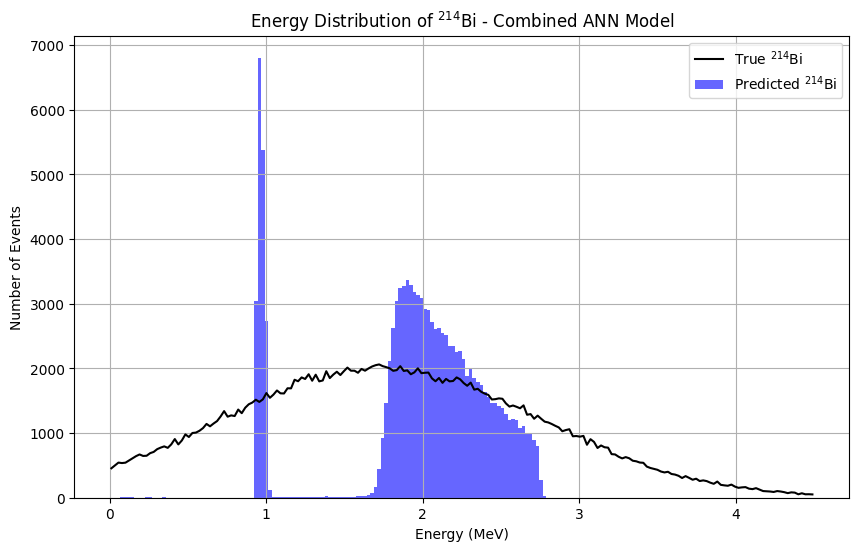

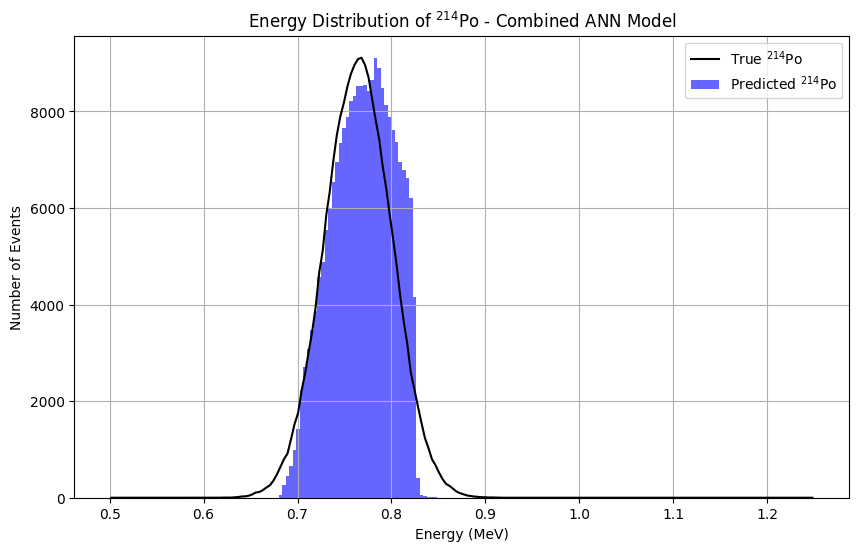

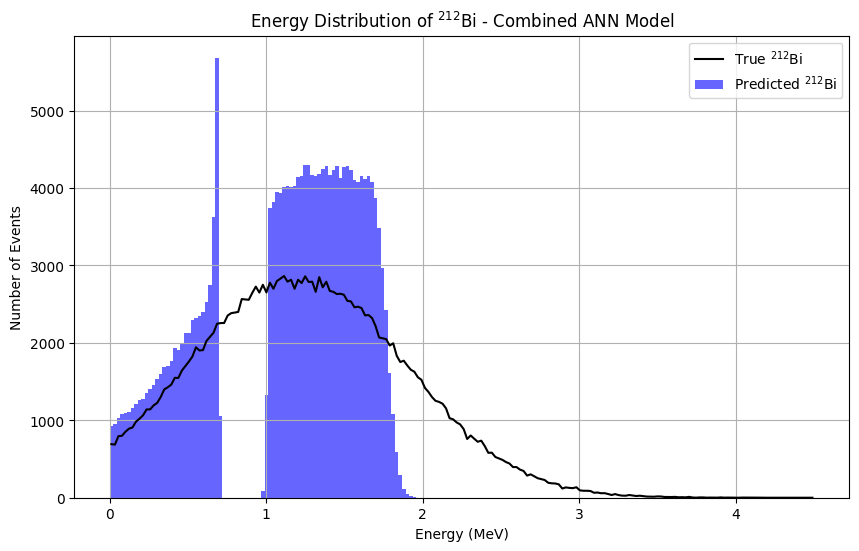

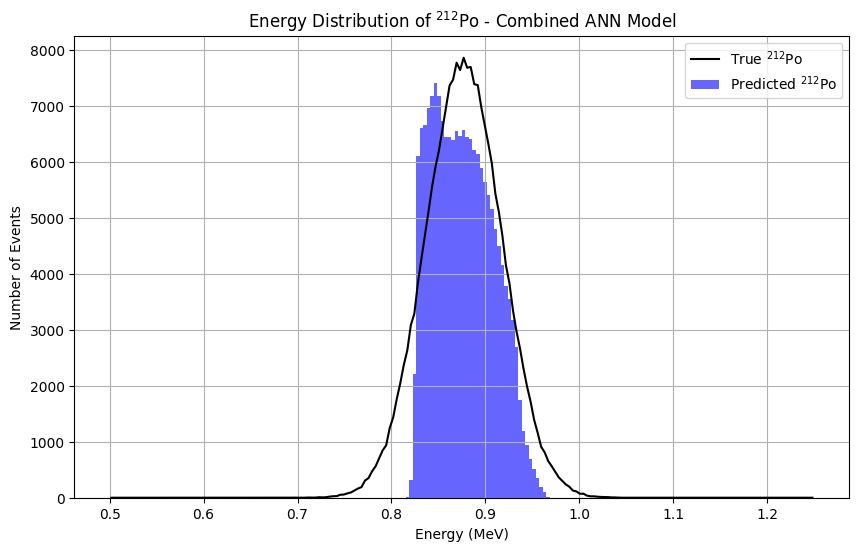

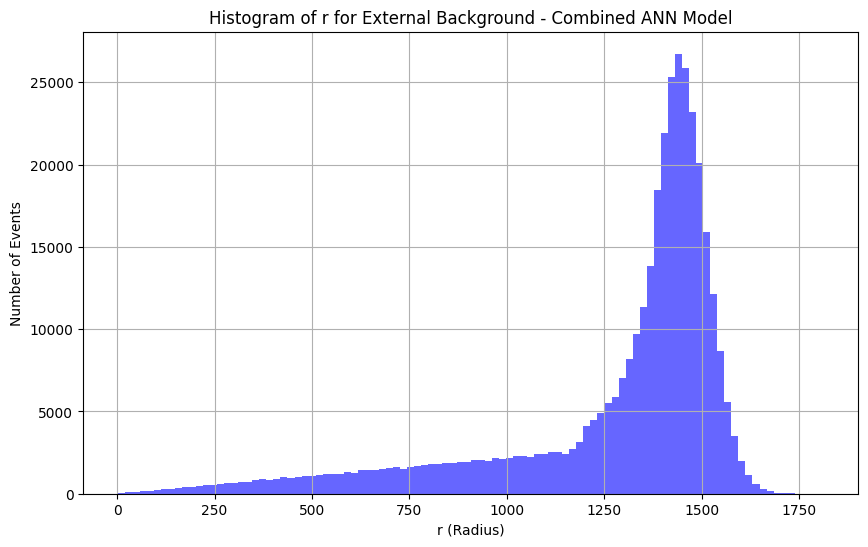

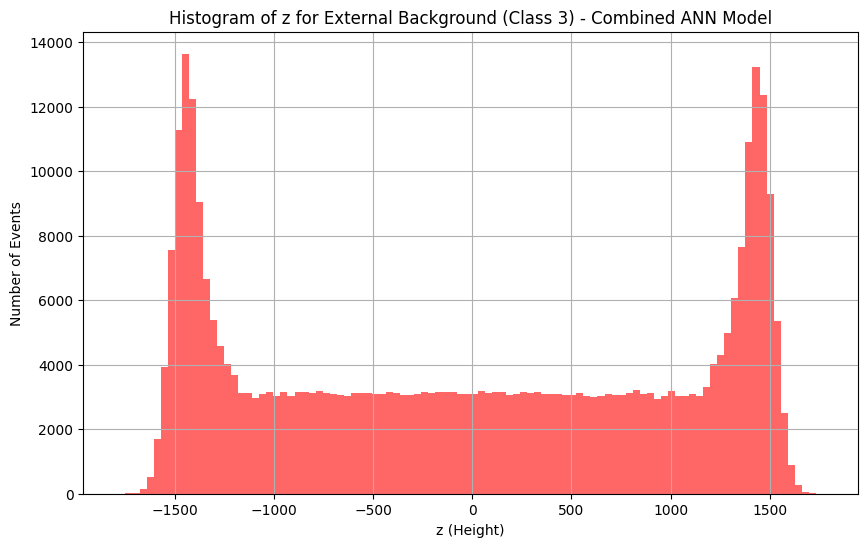

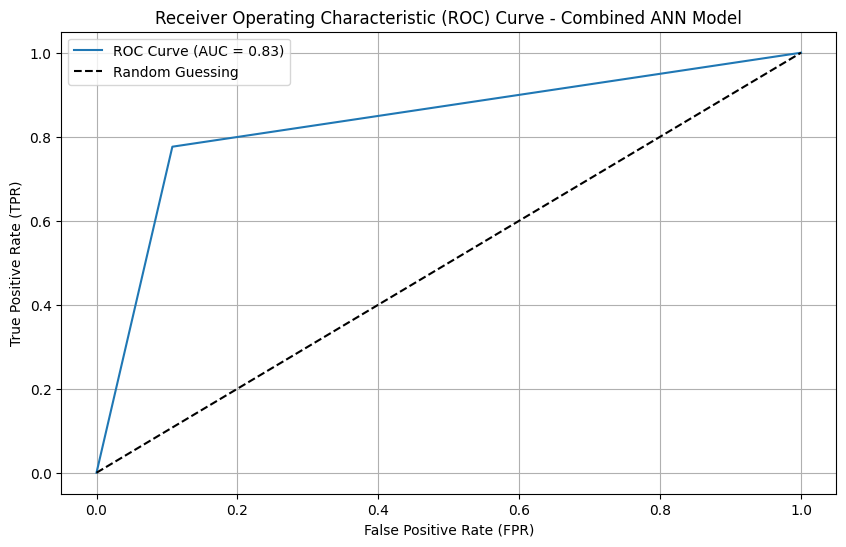

In [182]:
# Call the function and pass save_dir
plot_event_analysis(combined_df, y_pred, y_test, model_name="Combined ANN Model", save_dir=save_dir, event_types=[1, 2, 4, 5], save_plots=True)

In [183]:
model_name = "Combined ANN Model"
save_plots = True  # Set to False if you don't want to save plots

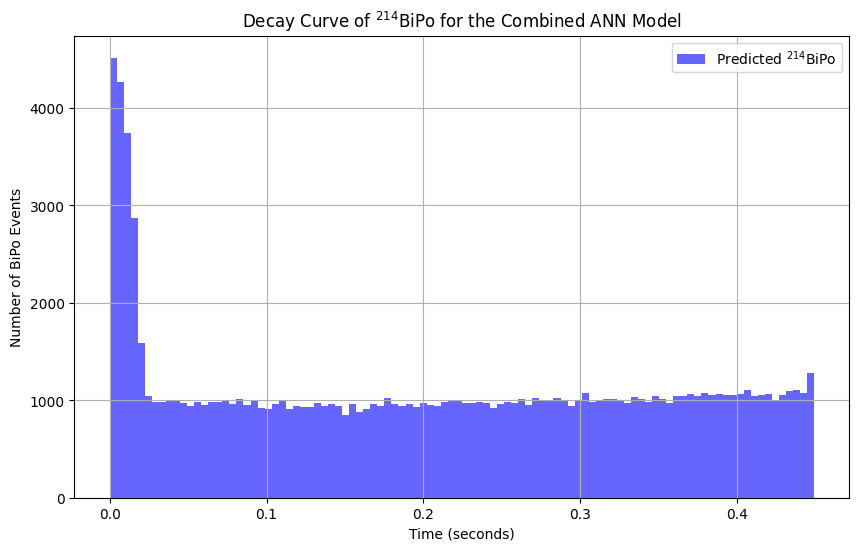

In [184]:
# Calculate time differences for Bi214 → Po214
time_diffs_bi_po214 = calculate_time_differences(X_test, y_pred, 1, 2)
# Plot decay curve for Bi214 → Po214
plot_decay_curve(time_diffs_bi_po214, r"$^{214}$BiPo", model_name, save_dir, save_plots)

In [185]:
# Plot zoomed-in decay curve for Bi214 → Po214 (example: xlim from 0 to 0.001 sec)
#plot_decay_curve(time_diffs_bi_po214, "Bi214 → Po214", model_name, save_dir, save_plots, xlim=(0, 0.001))

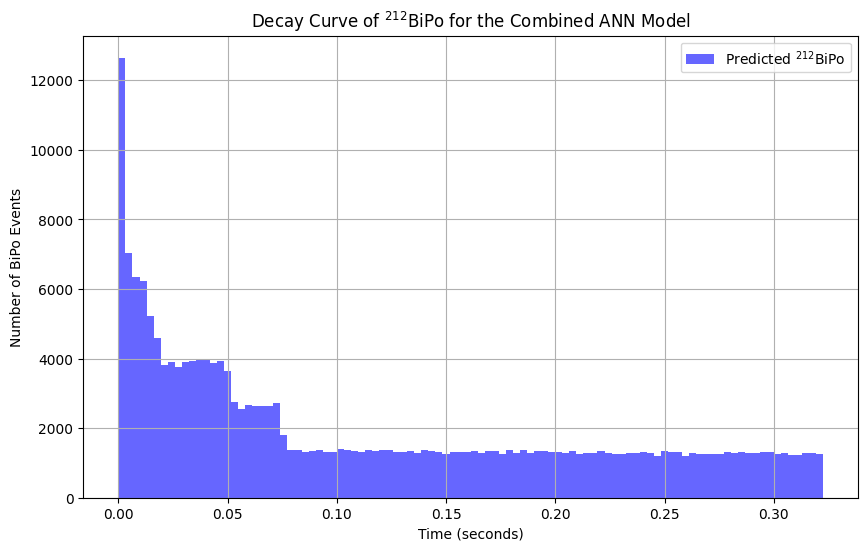

In [186]:
# Calculate time differences for Bi212 → Po212
time_diffs_bi_po212 = calculate_time_differences(X_test, y_pred, 4, 5)

# Plot decay curve for Bi212 → Po212
plot_decay_curve(time_diffs_bi_po212, r"$^{212}$BiPo", model_name, save_dir, save_plots)

In [187]:
# Plot zoomed-in decay curve for Bi212 → Po212
#plot_decay_curve(time_diffs_bi_po212, "Bi212 → Po212", model_name, save_dir, save_plots, xlim=(0, 0.001))